In [1]:
from SCFT_DNA.SCFT_functions import *
from SCFT_DNA.DNA_input import *
from plot_functions import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import hictkpy as htk
from matplotlib.colors import LogNorm

from pathlib import Path

from Bead_sequence_MC.mf_chromatin_functions import *
from scipy.stats import pearsonr

Using cupy


(200, 200)


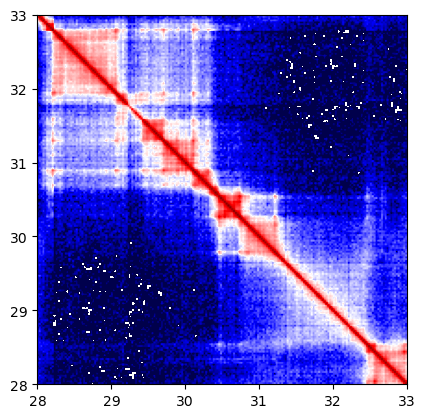

In [2]:
#hic_path = r"/Bead_sequence_MC/GSE63525_IMR90_combined_30.hic"
hic_path = Path.cwd().parent.parent / "Bead_sequence_MC" / "GSE63525_IMR90_combined_30.hic"

bin_size = 25_000
f = htk.File(hic_path, bin_size)

extent = (28,33,28,33)
sel = f.fetch("21:28,000,000-33,000,000")
m = sel.to_numpy()
#plt.imshow(np.log10(m), cmap="Reds",)
plt.imshow(m, norm=LogNorm(),cmap="seismic",extent=extent)
print(m.shape)

(80, 80)


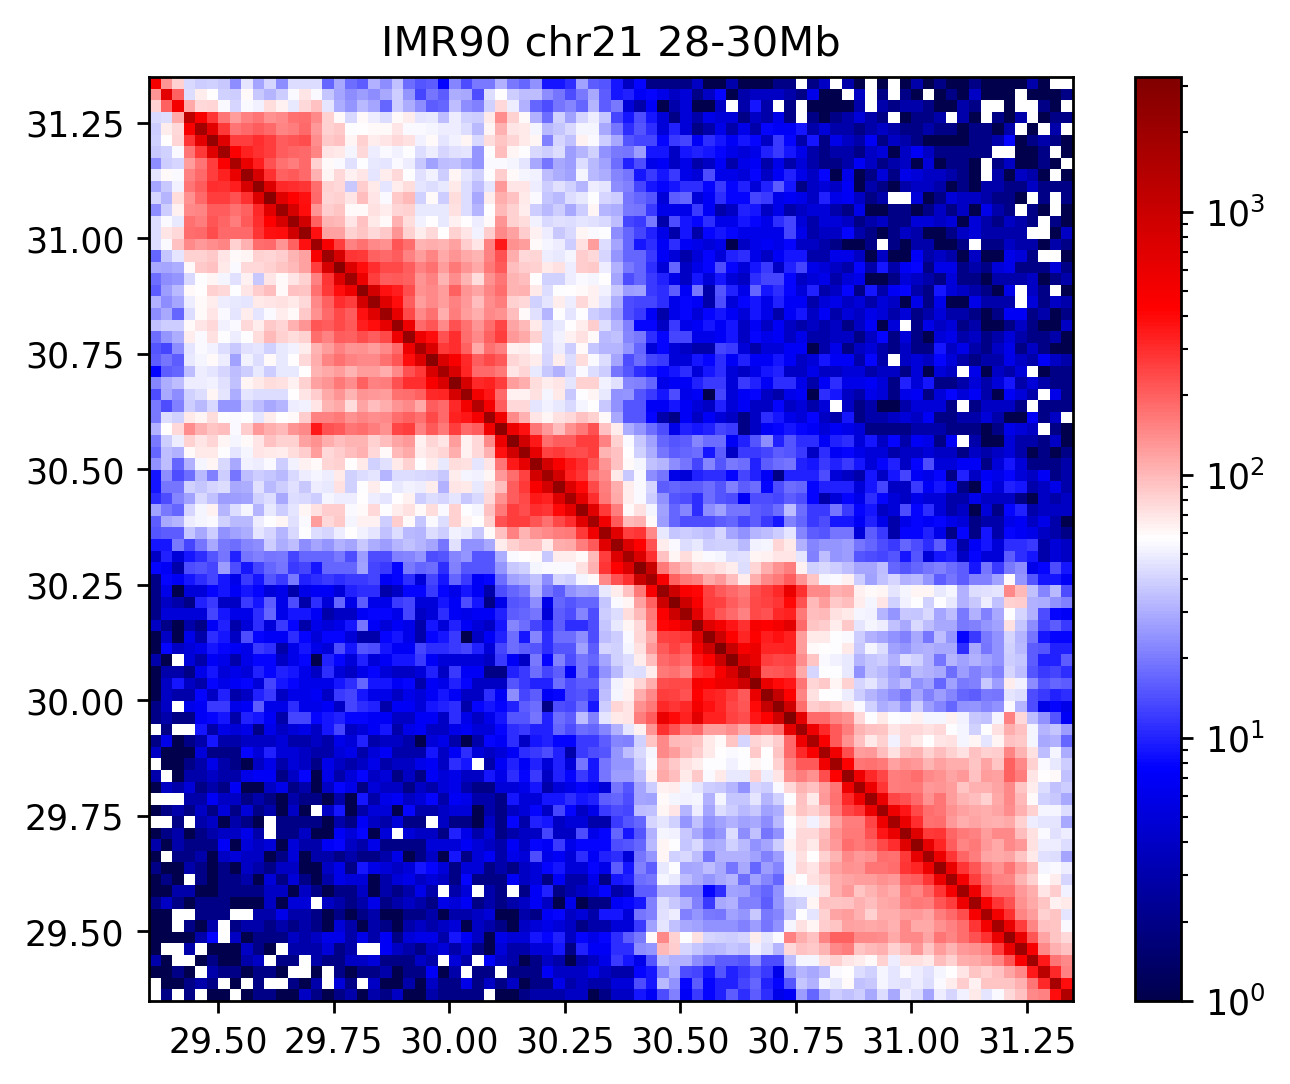

C:\Users\19162\AppData\Local\Temp\ipykernel_40816\3670231331.py:12: RuntimeWarning: divide by zero encountered in log10
  processed_log_matrix = fill_nearest(np.log10(Hi_C))


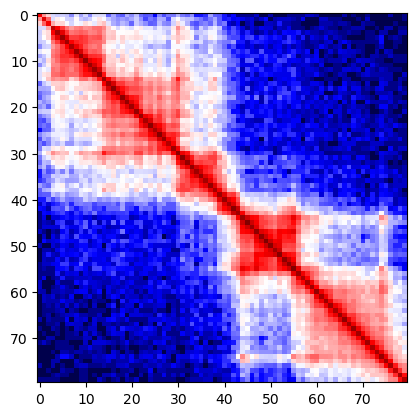

In [3]:
plt.figure(dpi=250)
extent = (29.35,31.35,29.35,31.35)
sel = f.fetch("21:29,350,000-31,350,000")
Hi_C = sel.to_numpy()
#plt.imshow(np.log10(m), cmap="Reds",)
plt.imshow(Hi_C, norm=LogNorm(),cmap="seismic",extent=extent)
plt.title("IMR90 chr21 28-30Mb")
print(Hi_C.shape)
plt.colorbar()
plt.show()

processed_log_matrix = fill_nearest(np.log10(Hi_C))
plt.imshow(processed_log_matrix, cmap="seismic",)
plt.show()

In [7]:
import gc
gc.disable()
corr_2d_grid = np.load("../results_parameter_sweep_phi01/corr_2d_grid.npy", allow_pickle=True)
free_energy_grid = np.load("../results_parameter_sweep_phi01/free_energy_grid.npy", allow_pickle=True)
None
gc.enable()
gc.collect()
#ChiNpp = np.array([50, 100, 150, 200, 250, 300, 325, 350, 400, 450])
#ChiNps = np.array([50, 100, 150, 200, 250, 300, 325, 350, 400, 450])
ChiNpp = np.array([200, 250, 300, 325, 350, 400, 450, 500, 550])
ChiNps = np.array([200, 250, 300, 325, 350, 400, 450])

In [8]:
fail_index = np.ones((len(ChiNpp), len(ChiNps)))
for i in range(len(ChiNpp)):
    for j in range(len(ChiNps)):
        free_energy_hist = np.array(free_energy_grid[i,j])
        if (np.max(abs(free_energy_hist)) < 160) & (free_energy_hist.shape[0] > 7900):
            fail_index[i,j] = False

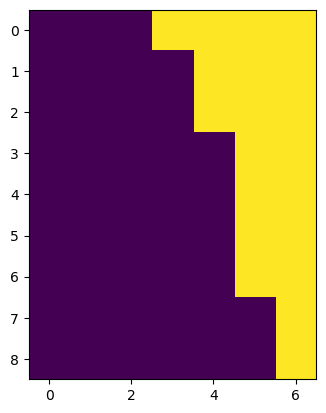

In [9]:
plt.imshow(fail_index)

Text(0.5, 1.0, 'Overlap map\n$\\chi N_{pp}=250,\\ \\chi N_{ps}=325$\nSCC = 0.65')

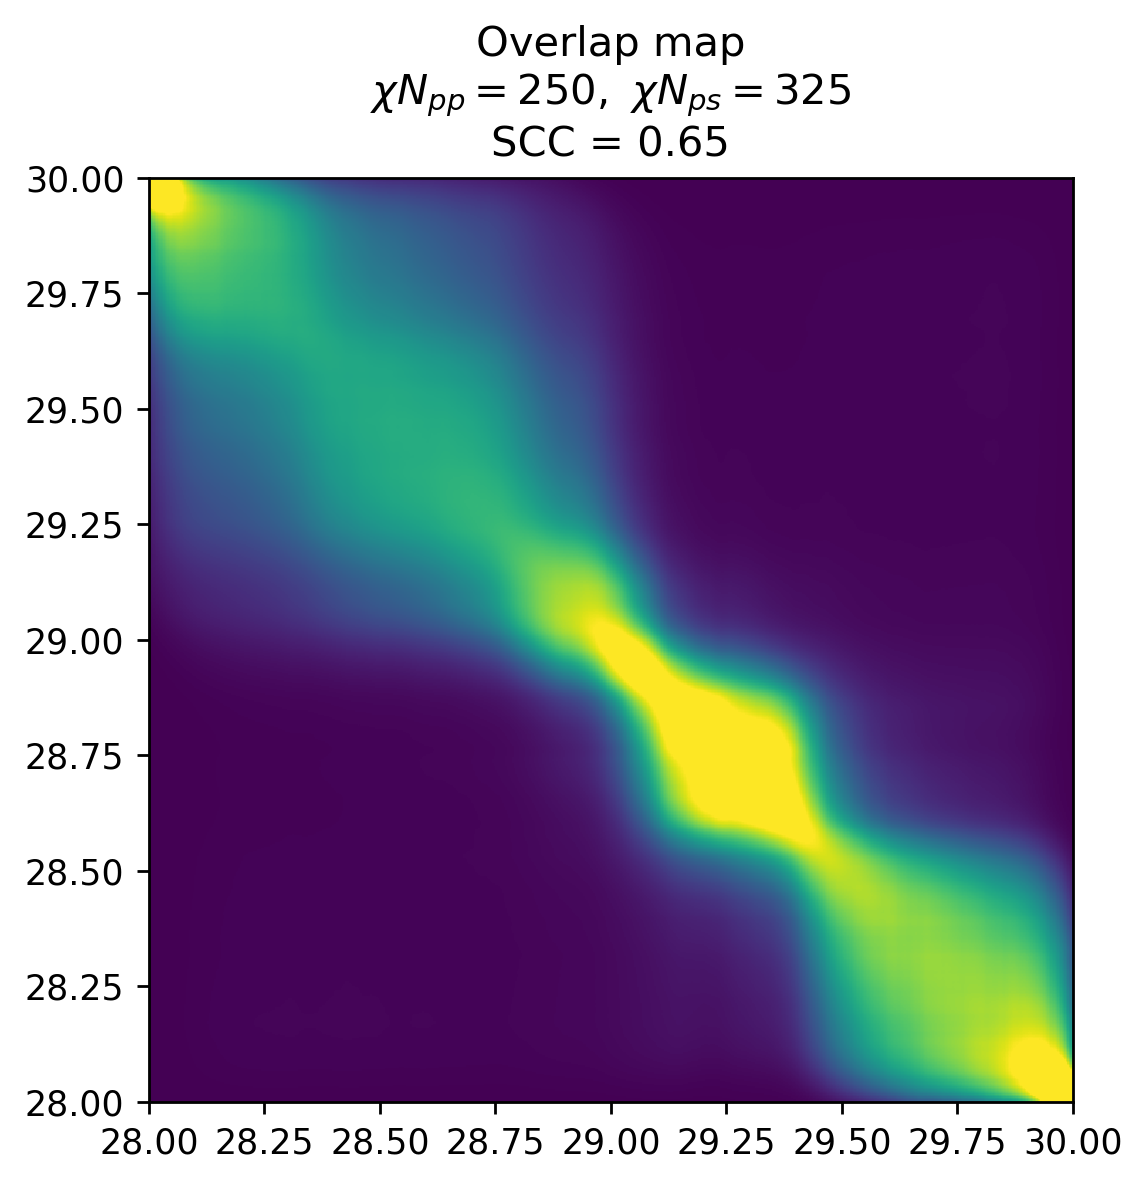

In [28]:
plt.figure(dpi=250)
crop_length = 20
corr_2d = np.copy(corr_2d_grid[4, 4])[crop_length:-crop_length, crop_length:-crop_length]

#normal_factor = np.mean(Hi_C)/np.mean(corr_2d)
#corr_2d = corr_2d * normal_factor

extent = (28,30,28,30)
dynamic_range = 3.3 * np.std(corr_2d)
plt.imshow(corr_2d, cmap='viridis', interpolation='nearest', aspect=1,
           #vmin=-dynamic_range,
           vmax=+dynamic_range,
           extent=extent
           )
#plt.colorbar()

#plt.title("Overlap map\n ChiNpp=250, ChiNps=325\n SCC = 0.65")
plt.title(r"""Overlap map
$\chi N_{pp}=250,\ \chi N_{ps}=325$
SCC = 0.65""")


In [11]:
import pandas as pd
import cooler
from hicrep import hicrepSCC

def dense_to_cool(path, M, *, chrom="chr1", bin_size=1, upper_triangle_only=True):
    """
    Write a dense NxN matrix to a .cool file.
    bin_size sets coordinate units; if you don't have bp, set bin_size=1 and treat dBPMax in bins.
    """
    M = np.asarray(M)
    n = M.shape[0]
    if M.shape != (n, n):
        raise ValueError("Matrix must be square")

    bins = pd.DataFrame({
        "chrom": [chrom] * n,
        "start": np.arange(n) * bin_size,
        "end": (np.arange(n) + 1) * bin_size
    })

    if upper_triangle_only:
        i, j = np.triu_indices(n, k=0)
    else:
        i, j = np.indices((n, n))
        i, j = i.ravel(), j.ravel()

    counts = M[i, j].ravel()
    nz = counts != 0
    pixels = pd.DataFrame({
        "bin1_id": i[nz],
        "bin2_id": j[nz],
        "count": counts[nz].astype(np.int64, copy=False)
    })

    cooler.create_cooler(path, bins=bins, pixels=pixels, ordered=True)

def hicrep_scc_from_dense(A, B, *, h=1, dBPMax=200, bin_size=1):
    """
    Compute HiCRep SCC using official hicrep package by writing temporary coolers.
    dBPMax is in the same units as bin_size; if bin_size=1, dBPMax is in bins.
    """
    dense_to_cool("A_tmp.cool", A, bin_size=bin_size)
    dense_to_cool("B_tmp.cool", B, bin_size=bin_size)

    coolA = cooler.Cooler("A_tmp.cool")
    coolB = cooler.Cooler("B_tmp.cool")

    scc_per_chrom = hicrepSCC(coolA, coolB, h, dBPMax, False)
    # single chrom -> single value in array-like output
    return float(np.asarray(scc_per_chrom).ravel()[0])

Text(0, 0.5, 'Contact frequency')

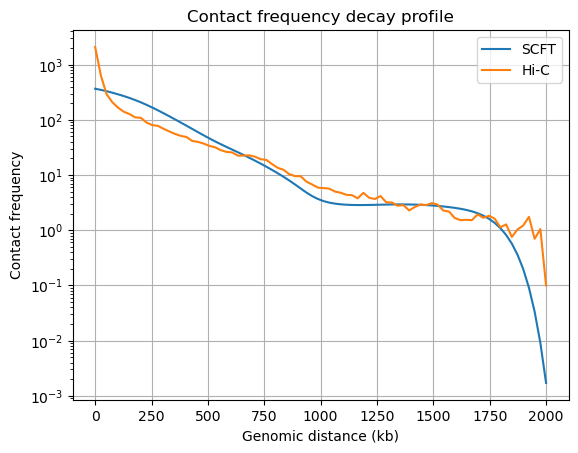

In [36]:
corr_2d = np.copy(corr_2d_grid[4, 4])[crop_length:-crop_length, crop_length:-crop_length]
zoomed_scft_matrix = resize_square(corr_2d, Hi_C.shape[0])

normal_factor = np.mean(Hi_C)/np.mean(zoomed_scft_matrix)
zoomed_scft_matrix = zoomed_scft_matrix * normal_factor

genomic_distance = np.linspace(0, 25*Hi_C.shape[0], num = Hi_C.shape[0], endpoint=True)

decay_scft, horiz, vert = diagonal_decay_profile(zoomed_scft_matrix, agg="mean", normalize=False)
plt.plot(genomic_distance, decay_scft, label="SCFT")

decay_hic, horiz, vert = diagonal_decay_profile(np.clip(Hi_C, 1e-1, np.inf), agg="mean", normalize=False)
plt.plot(genomic_distance, decay_hic, label="Hi-C")

plt.yscale("log")
#plt.xscale("log")
#plt.ylim(bottom = 1e-1)
plt.legend()
plt.title("Contact frequency decay profile")
plt.grid()
plt.xlabel("Genomic distance (kb)")
plt.ylabel("Contact frequency")

In [37]:
r, p = pearsonr(decay_scft, decay_hic)
print(r)

0.6193969303879714


0.9328201535207273


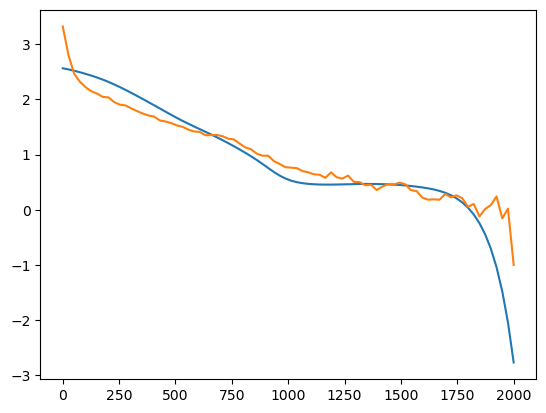

In [33]:
plt.plot(genomic_distance, np.log10(decay_scft), label="SCFT")
plt.plot(genomic_distance, np.log10(decay_hic), label="Hi-C")
r, p = pearsonr(np.log10(decay_scft), np.log10(decay_hic))
print(r)

In [34]:
#zoomed_log_scft_matrix = resize_square(corr_2d_log, Hi_C.shape[0])
zoomed_scft_corr = resize_square(corr_2d, Hi_C.shape[0])

scc = hicrep_scc_from_dense(zoomed_scft_corr, Hi_C, h=2, dBPMax=200, bin_size=1)
print(scc)

0.5241018386650542


C:\Users\19162\anaconda3\Lib\site-packages\hicrep\hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\


In [35]:
r, p = pearson_corr_distance_corrected(zoomed_scft_corr, Hi_C)
print('r = ', r)
print('p = ', p)

r =  0.32413014620734903
p =  3.331554096951874e-78


In [14]:
def imshow_grid(arrays, cmap=None, vmin=None, vmax=None,
                figsize=None, interpolation="nearest"):
    arrays = np.asarray(arrays)

    nx, ny = arrays.shape   # arrays is (nx, ny, H, W) or (nx, ny, ...)
    ncols = nx                  # x-axis in the big plot
    nrows = ny                  # y-axis in the big plot

    if figsize is None:
        figsize = (1.6 * ncols, 1.6 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)

    for r in range(nrows):          # r = y index
        for c in range(ncols):      # c = x index

            ax = axes[-r-1, c]
            img = np.copy(corr_2d_grid[c, r])[crop_length:-crop_length, crop_length:-crop_length]

            if fail_index[c,r] == True:
                img *= 0
            dynamic_range = 3.5 * np.std(img)
            ax.imshow(img, cmap=cmap, vmin=vmin, vmax=dynamic_range, interpolation=interpolation)
            ax.set_axis_off()

    plt.subplots_adjust(wspace=0.02, hspace=0.02)
    return fig, axes

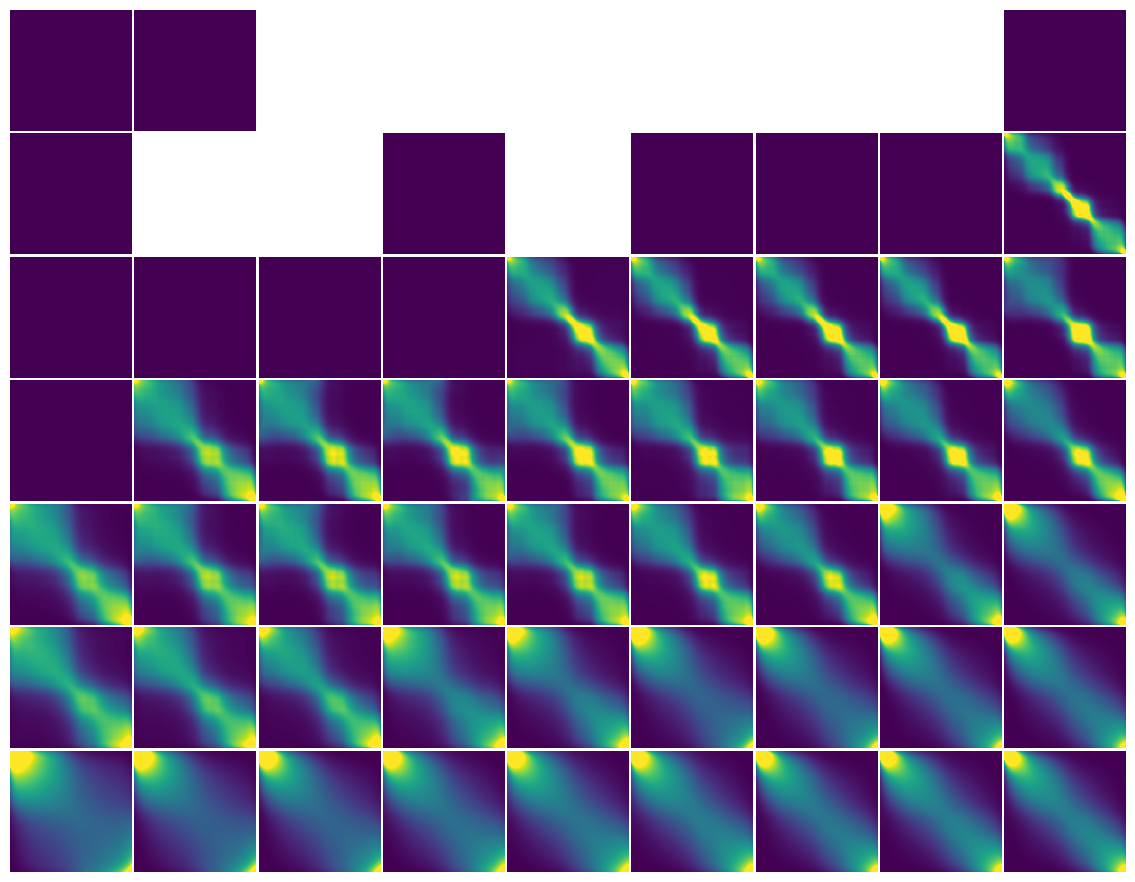

In [15]:
fig, axes = imshow_grid(corr_2d_grid, vmin=0)
plt.show()

In [ ]:
def calculate_scc_grid():
    M, K = corr_2d_grid.shape
    scc_grid = np.zeros((M, K))

    for i in range(M):
        for j in range(K):

            corr_2d = np.copy(corr_2d_grid[i, j])[crop_length:-crop_length, crop_length:-crop_length]
            zoomed_scft_corr = resize_square(corr_2d, Hi_C.shape[0])

            #scc = hicrep_scc_from_dense(zoomed_scft_corr, Hi_C, h=2, dBPMax=200, bin_size=1)
            #scc_grid[i, j] = scc
            #print("scc = ", scc)

            try:
                scc = hicrep_scc_from_dense(zoomed_scft_corr, Hi_C, h=2, dBPMax=200, bin_size=1)
                scc_grid[i, j] = scc
                print("scc = ", scc)
            except:
                scc_grid[i, j] = np.nan

            if fail_index[i, j] == True:
                scc_grid[i, j] = np.nan

    return scc_grid

scc_grid = calculate_scc_grid()

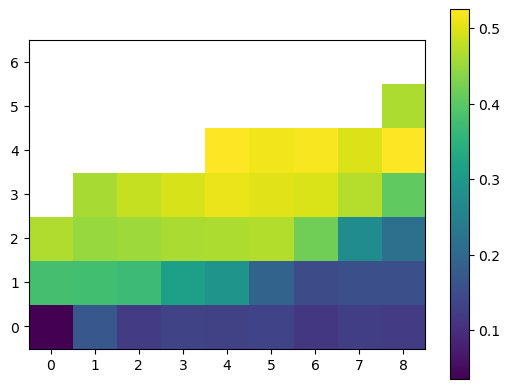

In [18]:
plt.imshow(scc_grid.T, origin='lower')
plt.colorbar()

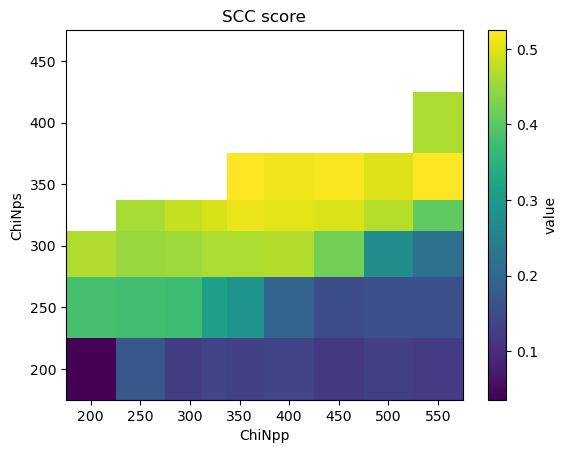

In [19]:
ax = plot_heatmap(scc_grid, ChiNpp, ChiNps, title="SCC score")
plt.show()

In [ ]:
def calculate_scc_log_grid():
    M, K = corr_2d_grid.shape
    scc_grid = np.zeros((M, K))

    for i in range(M):
        for j in range(K):

            corr_2d = np.copy(corr_2d_grid[i, j])[crop_length:-crop_length, crop_length:-crop_length]
            zoomed_scft_corr = resize_square(corr_2d, Hi_C.shape[0])

            log_zoomed_scft_corr = np.log10(zoomed_scft_corr)

            try:
                scc = hicrep_scc_from_dense(log_zoomed_scft_corr, processed_log_matrix, h=2, dBPMax=200, bin_size=1)
                scc_grid[i, j] = scc
            except:
                scc_grid[i, j] = np.nan

            if fail_index[i, j] == True:
                scc_grid[i, j] = np.nan

    return scc_grid

scc_log_grid = calculate_scc_log_grid()

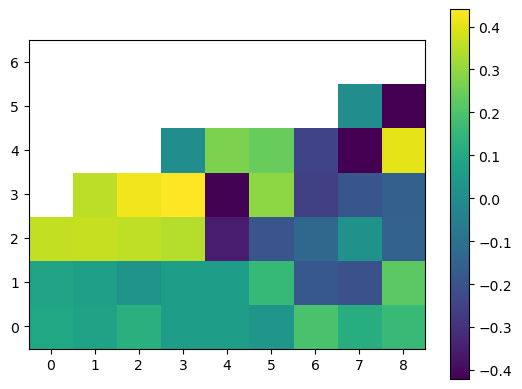

In [21]:
plt.imshow(scc_log_grid.T, origin='lower')
plt.colorbar()

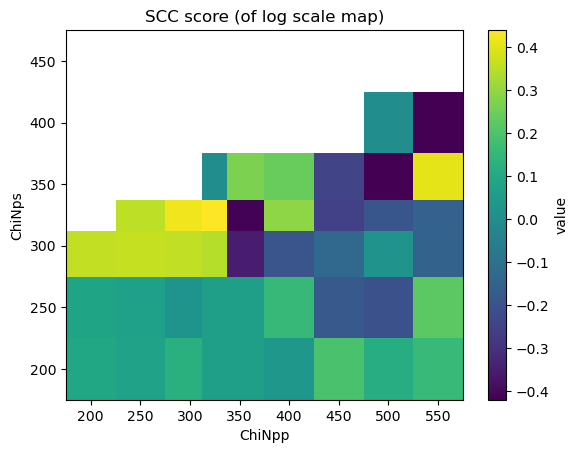

In [22]:
ax = plot_heatmap(scc_log_grid, ChiNpp, ChiNps, title="SCC score (of log scale map)")
plt.show()

In [23]:
def calculate_profile_fall_grid():
    M, K = corr_2d_grid.shape
    profile_fall_grid = np.zeros((M, K))

    for i in range(M):
        for j in range(K):

            corr_2d = np.copy(corr_2d_grid[i, j])[crop_length:-crop_length, crop_length:-crop_length]
            zoomed_scft_corr = resize_square(corr_2d, Hi_C.shape[0])


            normal_factor = np.mean(Hi_C)/np.mean(zoomed_scft_corr)
            zoomed_scft_corr = zoomed_scft_corr * normal_factor

            decay_scft, horiz, vert = diagonal_decay_profile(zoomed_scft_corr, agg="mean", normalize=False)

            decay_hic, horiz, vert = diagonal_decay_profile(np.clip(Hi_C, 1e-1, np.inf), agg="mean", normalize=False)

            try:
                r, p = pearsonr(np.log10(np.clip(decay_scft, 1e-5, np.inf)), np.log10(decay_hic))

                profile_fall_grid[i, j] = r
            except:
                profile_fall_grid[i, j] = np.nan

            if fail_index[i, j] == True:
                profile_fall_grid[i, j] = np.nan

    return profile_fall_grid

profile_fall_grid = calculate_profile_fall_grid()
profile_fall_grid[0,0] = np.nan # it's pointless to show it, and it affects the range of polt

C:\Users\19162\AppData\Local\Temp\ipykernel_40816\858546346.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  normal_factor = np.mean(Hi_C)/np.mean(zoomed_scft_corr)
C:\Users\19162\AppData\Local\Temp\ipykernel_40816\858546346.py:13: RuntimeWarning: invalid value encountered in multiply
  zoomed_scft_corr = zoomed_scft_corr * normal_factor
C:\Softwares\scft-for-brached-and-confined-polymers-by-yuchen\Bead_sequence_MC\mf_chromatin_functions\analysis.py:28: RuntimeWarning: Mean of empty slice
  horiz = np.array([reducer(np.diagonal(A, offset=k)) for k in range(N)])
C:\Softwares\scft-for-brached-and-confined-polymers-by-yuchen\Bead_sequence_MC\mf_chromatin_functions\analysis.py:30: RuntimeWarning: Mean of empty slice
  vert  = np.array([reducer(np.diagonal(A, offset=-k)) for k in range(N)])


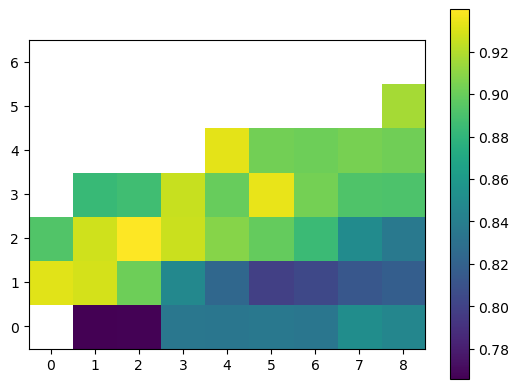

In [24]:
plt.imshow(profile_fall_grid.T, origin='lower')
plt.colorbar()

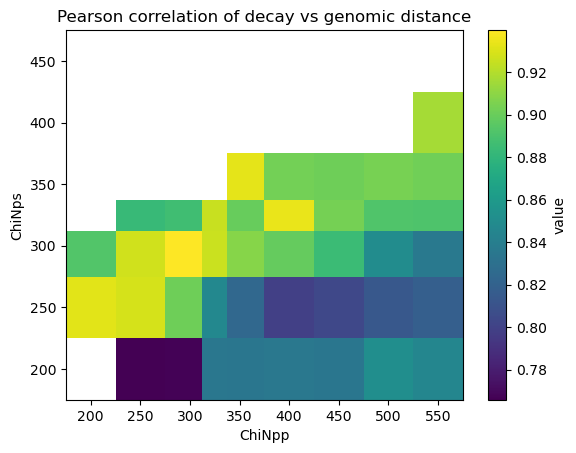

In [25]:
ax = plot_heatmap(profile_fall_grid, ChiNpp, ChiNps, title="Pearson correlation of decay vs genomic distance")
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decay_grid(
    corr_2d_grid, Hi_C, crop_length,
    *, cmap=None, vmin=None, vmax=None,  # unused here; kept if you want symmetry with your other function
    figsize=None, interpolation="nearest", # unused here
    yscale="log",
    sharex=True, sharey=True,
    show_legend=False
):
    """
    corr_2d_grid: array shaped (nx, ny, H, W) (or larger last dims, as long as you index [i,j] -> 2D)
    Hi_C:         2D square matrix
    crop_length:  int, crop from each side before resize
    """
    corr_2d_grid = np.asarray(corr_2d_grid)
    nx, ny = corr_2d_grid.shape[:2]
    ncols, nrows = nx, ny

    # Precompute Hi-C decay once (same for every subplot)
    decay_hic, _, _ = diagonal_decay_profile(np.clip(Hi_C, 1e-1, np.inf), agg="mean", normalize=False)

    if figsize is None:
        figsize = (2.2 * ncols, 2.0 * nrows)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        squeeze=False,
        sharex=sharex,
        sharey=sharey
    )

    for r in range(nrows):              # y index in your data
        for c in range(ncols):          # x index in your data
            if fail_index[c,r] == False:

                ax = axes[-r-1, c]

                # --- build zoomed_scft_matrix for this (c, r) tile ---
                corr_2d = np.copy(corr_2d_grid[c, r])

                if crop_length and crop_length > 0:
                    corr_2d = corr_2d[crop_length:-crop_length, crop_length:-crop_length]

                zoomed_scft_matrix = resize_square(corr_2d, Hi_C.shape[0])

                normal_factor = np.mean(Hi_C) / np.mean(corr_2d)
                zoomed_scft_matrix = zoomed_scft_matrix * normal_factor

                decay_scft, _, _ = diagonal_decay_profile(zoomed_scft_matrix, agg="mean", normalize=False)

                # Plot (trim to common length if needed)
                ax.plot(decay_scft, label="SCFT")
                ax.plot(decay_hic,  label="Hi-C")

                if yscale is not None:
                    ax.set_yscale(yscale)
                #ax.set_xscale("log")

                ax.set_ylim(bottom=1e-2)
                # Optional: reduce clutter
                ax.tick_params(labelsize=8)

                if show_legend and (r == 0 and c == 0):
                    ax.legend(frameon=False, fontsize=9)

    plt.subplots_adjust(wspace=0.15, hspace=0.15)
    return fig, axes


C:\Users\19162\AppData\Local\Temp\ipykernel_40816\1456511695.py:49: RuntimeWarning: divide by zero encountered in scalar divide
  normal_factor = np.mean(Hi_C) / np.mean(corr_2d)
C:\Users\19162\AppData\Local\Temp\ipykernel_40816\1456511695.py:50: RuntimeWarning: invalid value encountered in multiply
  zoomed_scft_matrix = zoomed_scft_matrix * normal_factor


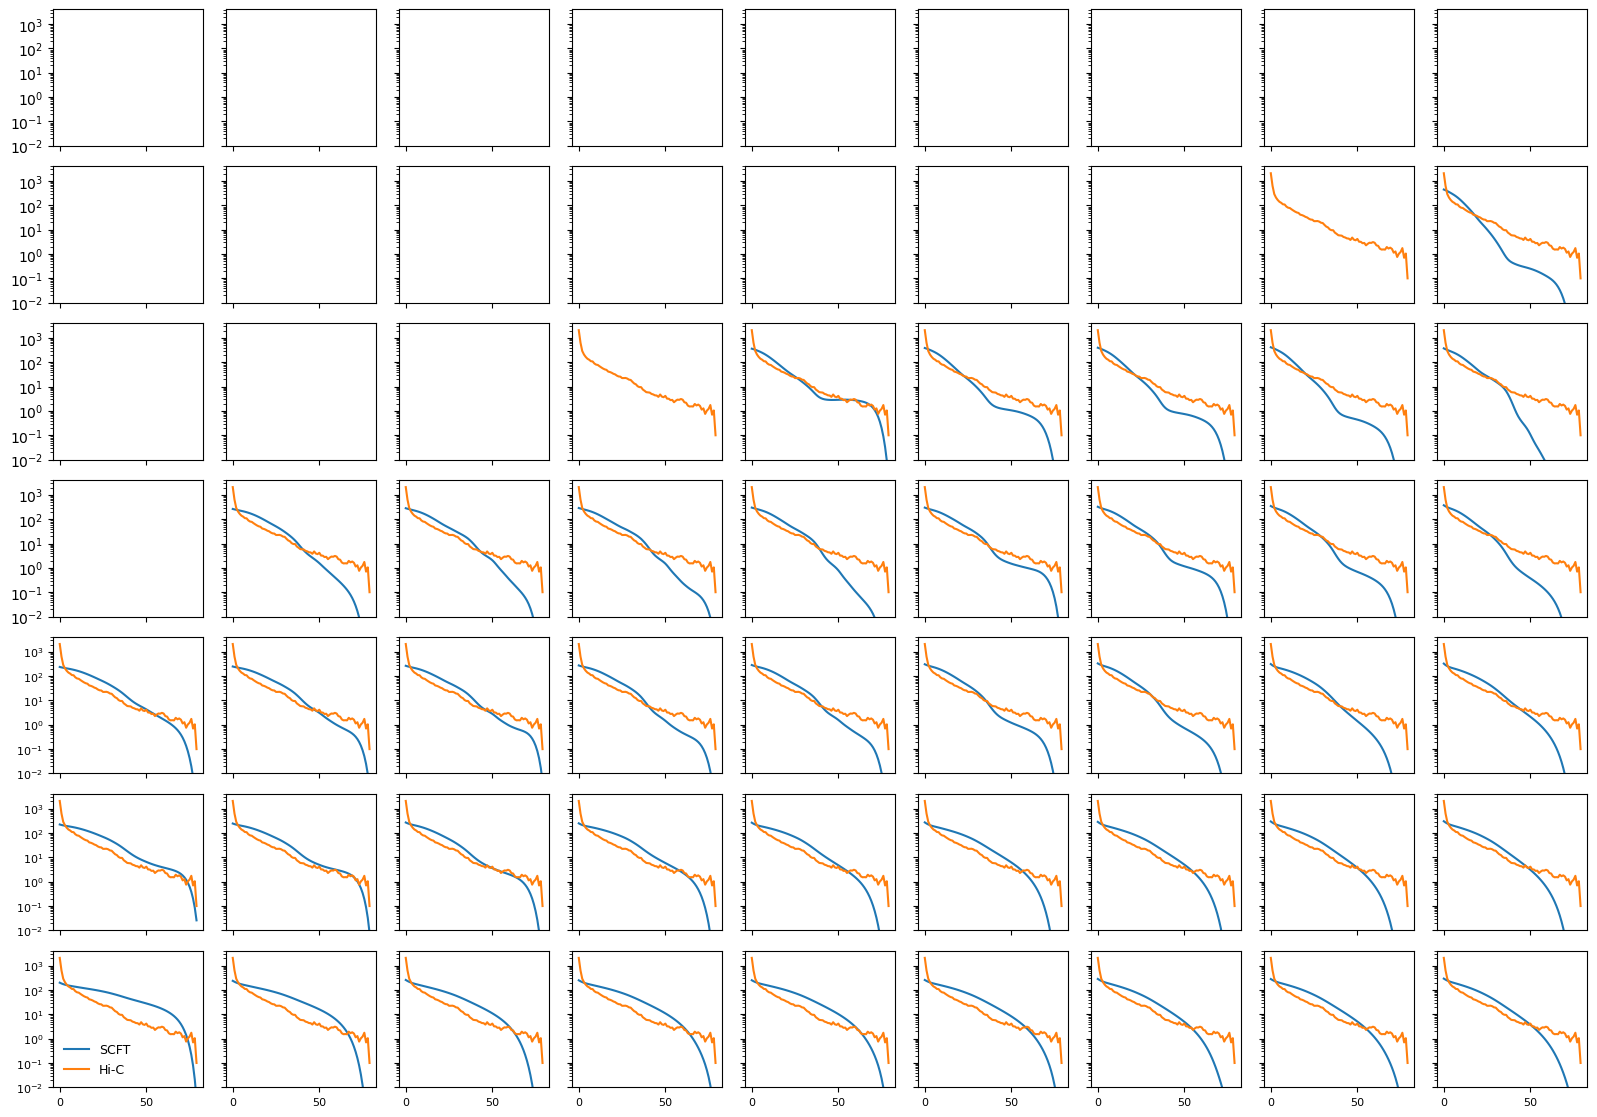

In [27]:
fig, axes = plot_decay_grid(
    corr_2d_grid=corr_2d_grid,   # shape (nx, ny, ...)
    Hi_C=Hi_C,
    crop_length=crop_length,
    yscale="log",
    show_legend=True
)
plt.show()

In [ ]:
def corr_sweep_2d(comp_its):

    M, K = corr_2d_grid.shape
    for i in range(M):
        for j in range(K):
            plt.close('all')

            print(f"PP = {int(ChiNpp[i])},  PS = {ChiNps[j]:g}")
            print('ij = ', i, j)

            free_energy_hist = np.array(free_energy_grid[i,j])
            if free_energy_hist.shape[0] == comp_its:

                corr_2d = np.copy(corr_2d_grid[i, j])[crop_length:-crop_length, crop_length:-crop_length]

                #corr_2d = np.sqrt(corr_2d)
                #corr_2d_log = np.log10(corr_2d)

                #zoomed_scft_matrix = resize_square(corr_2d_log, Hi_C.shape[0])
                zoomed_scft_corr = resize_square(corr_2d, Hi_C.shape[0])
                '''
                r, p = pearson_corr_distance_corrected(zoomed_scft_matrix, processed_log_matrix)
                print('r = ', r)
                print('p = ', p)
                '''
                #scc = hicrep_scc_from_dense(processed_log_matrix, zoomed_scft_matrix, h=2, dBPMax=200, bin_size=1)
                try:
                    scc = hicrep_scc_from_dense(zoomed_scft_corr, Hi_C, h=2, dBPMax=200, bin_size=1)
                    print("HiCRep SCC:", scc)
                except:
                    print("SCC fail")
                dynamic_range = 3.5 * np.std(corr_2d)
                plt.imshow(corr_2d, cmap='viridis', interpolation='nearest', aspect=1,
                           #vmin=-dynamic_range,
                           vmax=+dynamic_range
                           )
                plt.colorbar()
                plt.show()
            else:
                print("FAIL")

In [ ]:
corr_sweep_2d(8000)